# Data Analysis

Log

- 19/01/2025: Init

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn.preprocessing as skp
from rich import print as rprint

## Helpers

In [2]:
def extract_nr_of_sd_attributes(x: str) -> int:
    mi = re.match('.*-sd-(\d{3})-att', x)
    if mi is None or len(mi.groups()) < 1:
        raise Exception(f'Could not extract the number of selectively disclosed attributes from the given input string: {x}')
    return int(mi.group(1))

## Data

In [3]:
!ls -l data/

total 61896
-rw-r--r--  1 gertjandm  staff   3024778 Jan 29 02:15 records-202501290231.json
-rw-r--r--  1 gertjandm  staff   4503929 Feb  6 14:47 records-202502062144.json
-rw-r--r--  1 gertjandm  staff   9033480 Feb  7 00:33 records-202502070033.json
-rw-r--r--@ 1 gertjandm  staff     13995 Feb  7 02:04 records-202502070033.xlsx
-rw-r--r--  1 gertjandm  staff  15082337 Feb  7 01:42 records-202502070205.json
-rw-r--r--  1 gertjandm  staff     14014 Feb 10 15:32 records-202502070205.xlsx
-rw-r--r--@ 1 gertjandm  staff       165 Feb 10 12:44 ~$records-202502070033.xlsx


In [4]:
# default
fpath_records = './data/records.json'

#fpath_records = './data/records-202501290231.json'
#fpath_records = './data/records-202502062144.json'
#fpath_records = './data/records-202502070033.json'
fpath_records = './data/records-202502070205.json'

bname_records = os.path.basename(fpath_records).replace('.json','')
fpath_xl_output = os.path.join('data',f'{bname_records}.xlsx')
def get_df() -> pd.DataFrame:
    rprint(f'[bold red] Creating df from {fpath_records}')
    return pd.read_json(fpath_records)

In [5]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

 Creating df from ./data/records-202502070205.json

df.shape:  (12000, 8)
df ∑nRecords:  84000
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc01-sd-002-att,3,2,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc01-sd-002-att,3,2,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
11997,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,Iso18013DriversLicenseCredential-sd-016-att,21,16,499
11998,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,Iso18013DriversLicenseCredential-sd-016-att,21,16,499
11999,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,21,16,499


a.shape:  (84000, 8)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0


b.shape:  (84000, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,688.945167,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,821.288959,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,821.726584,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [6]:
c = a[['iteration','implementationClass', 'credentialSetupKey', 'nrCredentialSubjectAttributes', 'nrDisclosedCredentialSubjectAttributes']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (84000, 8)


,iteration,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,START_SIGN_VC,mark,688.945167
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,END_SIGN_VC,mark,821.288959
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,START_VERIFY_VC,mark,821.726584


Filter: only keep `mark` entries.

In [7]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (84000, 8)


,iteration,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,START_SIGN_VC,mark,688.945167
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,END_SIGN_VC,mark,821.288959
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,START_VERIFY_VC,mark,821.726584


Some final preprocessing.

In [8]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (84000, 8)


,iteration,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,startTime,implementation,step,stepType
0,0,vc01-sd-002-att,3,2,688.945167,BbsBlsSignature2020,SIGN_VC,START
0,0,vc01-sd-002-att,3,2,821.288959,BbsBlsSignature2020,SIGN_VC,END
0,0,vc01-sd-002-att,3,2,821.726584,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [9]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

In [10]:
def get_df_meta() -> pd.DataFrame:
    df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()
    df_meta['nrHiddenCredentialSubjectAttributes'] = df_meta['nrCredentialSubjectAttributes'] - df_meta['nrDisclosedCredentialSubjectAttributes']
    return df_meta
    

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [11]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (84000, 3)


nrCredentialSubjectAttributes  \
implementation      credentialSetupKey iteration step      stepType                                  
BbsBlsSignature2020 vc01-sd-002-att    0         SIGN_VC   START                                 3   
                                                           END                                   3   
                                                 VERIFY_VC START                                 3   

                                                                     nrDisclosedCredentialSubjectAttributes  \
implementation      credentialSetupKey iteration step      stepType                                           
BbsBlsSignature2020 vc01-sd-002-att    0         SIGN_VC   START                                          2   
                                                           END                                            2   
                                                 VERIFY_VC START                                          2   

                                                                      startTime  
implementation      credentialSetupKey iteration step      stepType              
BbsBlsSignature2020 vc01-sd-002-att    0         SIGN_VC   START     688.945167  
                                                           END       821.288959  
                                                 VERIFY_VC START     821.726584

### Sanity checks

In [12]:
# Make sure that every experiment has the same nr of records
assert dfa\
    .reset_index().groupby(['credentialSetupKey', 'implementation', 'step','stepType', 'iteration'],as_index=False ).first()\
    .groupby(['credentialSetupKey', 'implementation', 'step', 'stepType']).size()\
    .unique().__len__() == 1

### Compute delta execution time for each step

In [13]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')

# merge with credential meta
df_delta.reset_index().merge(get_df_meta(), left_on='credentialSetupKey', right_on='credentialSetupKey').set_index(list(df_delta.index.names))

print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (42000, 1)


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2359744582.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


delta
implementation      credentialSetupKey                          iteration step                      
BbsBlsSignature2020 Iso18013DriversLicenseCredential-sd-002-att 0         DERIVE          140.345167
                                                                          SIGN_VC          29.077417
                                                                          VERIFY_DERIVED   46.609083

### Compute descriptive statistics

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [14]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          111.142169   
                                                                 SIGN_VC          28.046988   
                                                                 VERIFY_DERIVED   47.142843   
                                                                 VERIFY_VC        56.383875   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          111.887995   
...                                                                                     ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC         2.782773   
                     vc01-sd-002-att                             SIGN_VC          15.153052   
                                                                 VERIFY_VC        14.300202   
                     vc02-sd-002-att                             SIGN_VC          14.745361   
                                                                 VERIFY_VC        13.750415   

                                                                                      std  \
implementation       credentialSetupKey                          step                       
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          7.500092   
                                                                 SIGN_VC         3.831276   
                                                                 VERIFY_DERIVED  7.798044   
                                                                 VERIFY_VC       6.452817   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          6.986196   
...                                                                                   ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC       0.455871   
                     vc01-sd-002-att                             SIGN_VC         2.212405   
                                                                 VERIFY_VC       2.773686   
                     vc02-sd-002-att                             SIGN_VC         2.852820   
                                                                 VERIFY_VC       1.484637   

                                                                                       var  \
implementation       credentialSetupKey                          step                        
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          56.251385   
                                                                 SIGN_VC         14.678678   
                                                                 VERIFY_DERIVED  60.809492   
                                                                 VERIFY_VC       41.638850   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          48.806938   
...                                                                                    ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC        0.207818   
                     vc01-sd-002-att                             SIGN_VC          4.894735   
                                                                 VERIFY_VC        7.693332   
                     vc02-sd-002-att                             SIGN_VC          8.138583   
                                                                 VERIFY_VC        2.204146   

                                                                                        min  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          106.472208   
                                                                 SIGN_VC          26.824000   
                                      

### Mean execution times

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [15]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['implementation','credentialSetupKey',],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  28.05   
VERIFY_VC                                                56.38   
DERIVE                                                  111.14   
VERIFY_DERIVED                                           47.14   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  27.69   
VERIFY_VC                                                56.74   
DERIVE                                                  111.89   
VERIFY_DERIVED                                           47.77   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  27.59   
VERIFY_VC                                                57.39   
DERIVE                                                  111.65   
VERIFY_DERIVED                                           48.39   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  27.91   
VERIFY_VC                                                59.78   
DERIVE                                                  120.11   
VERIFY_DERIVED                                           50.65   

implementation                                      \
credentialSetupKey vc01-sd-002-att vc02-sd-002-att   
step                                                 
SIGN_VC                      68.33           70.17   
VERIFY_VC                    43.12           50.29   
DERIVE                      194.01          221.96   
VERIFY_DERIVED               42.50           46.56   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  94.47   
VERIFY_VC                                               106.10   
DERIVE                                                  236.20   
VERIFY_DERIVED                                          125.83   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  94.51   
VERIFY_VC                                               104.99   
DERIVE                                                  234.91   
VERIFY_DERIVED                                          126.95   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  93.41   
VERIFY_VC                                               103.94   
DERIVE                                                  231.68   
VERIFY_DERIVED                                          126.29   

implementation                                                  ...  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att  ...   
step                                                            ...   
SIGN_VC                                                  94.91  ...   
VERIFY_VC                                               105.79  ...   
DERIVE                   

In [16]:
df_stat.to_excel(fpath_xl_output, 'mean_execution_times')

Preparing the (seaborn) dataframe for plotting.

In [17]:
dfsb = df_delta.reset_index()
dfsb['n_sd_att'] = dfsb.credentialSetupKey.apply(extract_nr_of_sd_attributes)
dfsb['credential'] = dfsb.credentialSetupKey.str.split('-sd').apply(lambda x: x[0])

print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (42000, 7)


,implementation,credentialSetupKey,iteration,step,delta,n_sd_att,credential
0,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,DERIVE,140.345167,2,Iso18013DriversLicenseCredential
1,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,SIGN_VC,29.077417,2,Iso18013DriversLicenseCredential
2,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,VERIFY_DERIVED,46.609083,2,Iso18013DriversLicenseCredential


Gather which credentials where found in the performance records.

In [18]:
evaluated_credentials = list(dfsb.credential.unique())
evaluated_credentials

['Iso18013DriversLicenseCredential', 'vc01', 'vc02']

Obtain a sorted list of crypto suite implementations found in the performance records.

In [19]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


### Considering all credential setups together

In [20]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)
csk_vc

Iso18013DriversLicenseCredential-sd-002-att    7000
Iso18013DriversLicenseCredential-sd-004-att    7000
Iso18013DriversLicenseCredential-sd-008-att    7000
Iso18013DriversLicenseCredential-sd-016-att    7000
vc01-sd-002-att                                7000
vc02-sd-002-att                                7000
Name: credentialSetupKey, dtype: int64

#### Plot mean execution time per VC operation per crypto suite across all input credentials

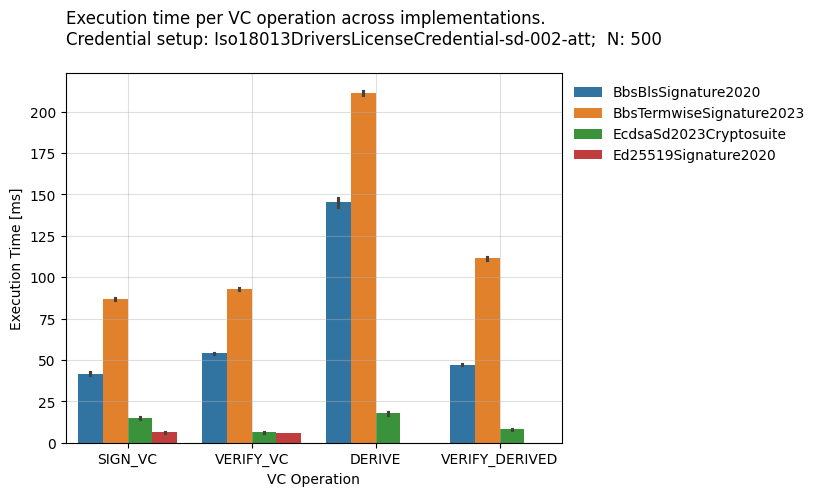

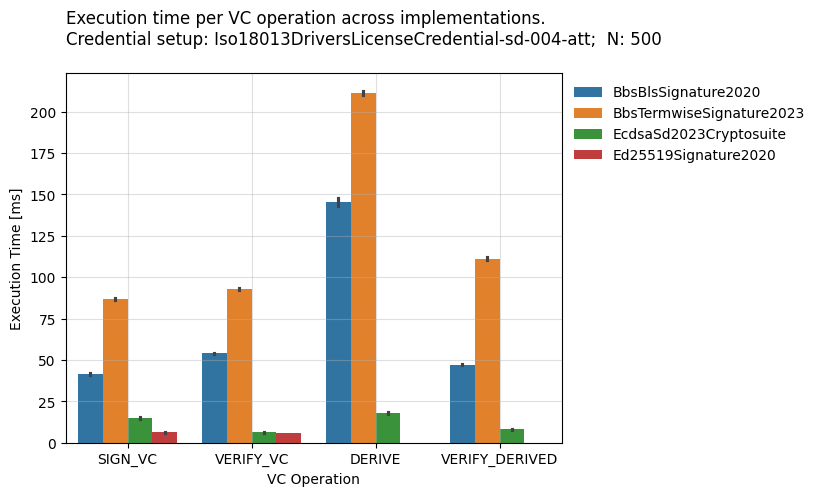

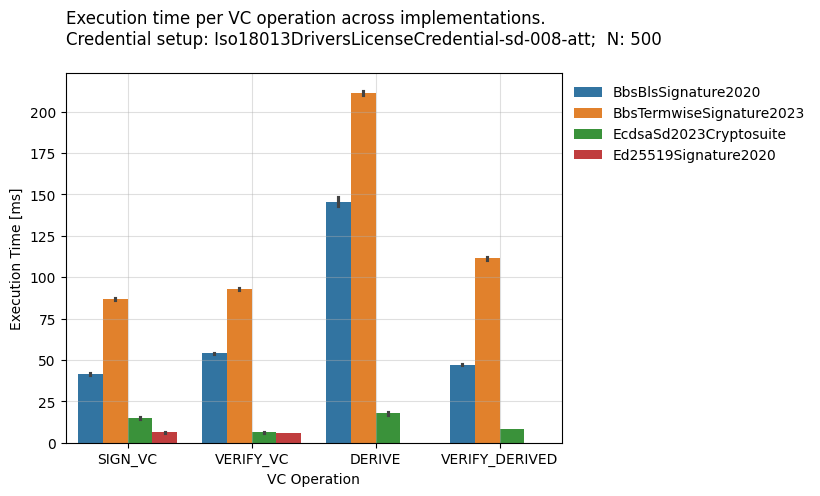

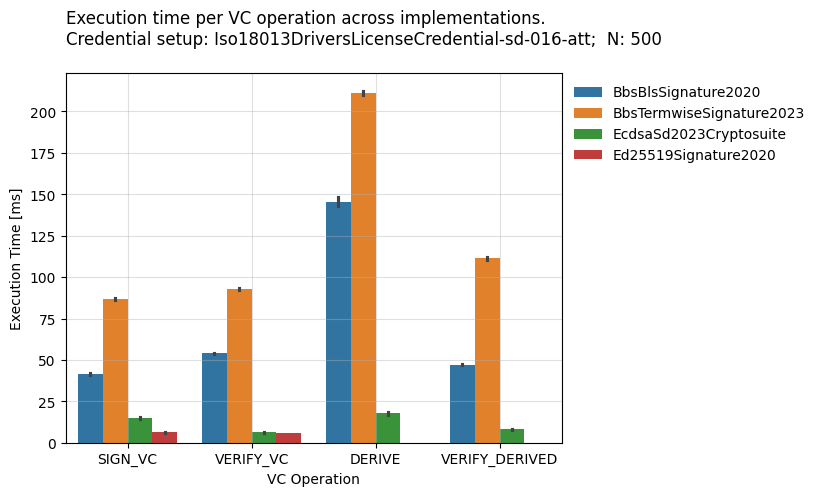

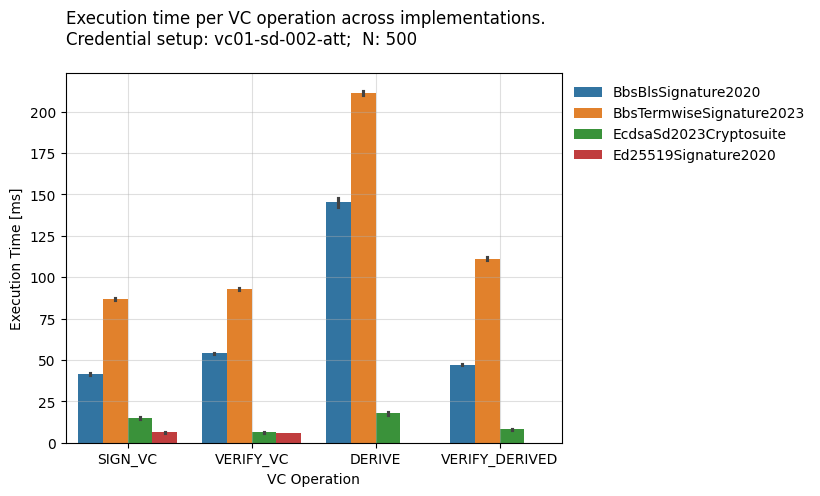

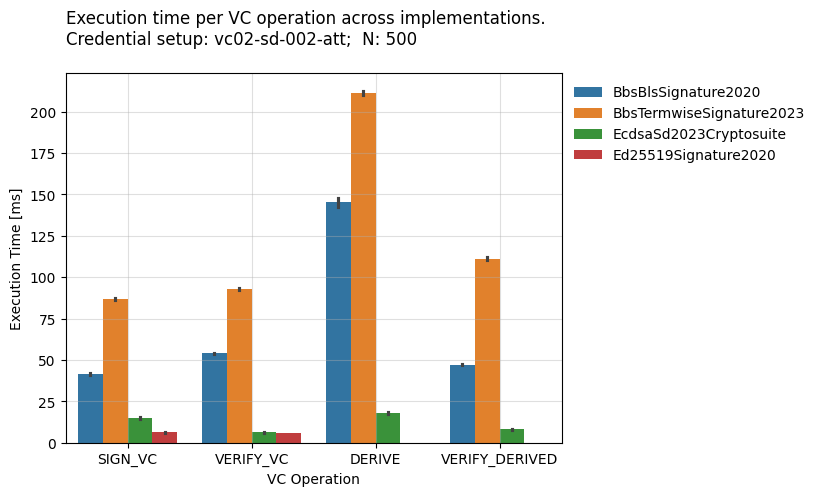

In [21]:
for csk in csk_vc.index:
    N = dfsb.iteration.max() + 1
    
    ax = sns.barplot(
        data = dfsb,
        x = 'step',
        y = 'delta',
        hue = 'implementation',
        order=step_order,
        hue_order=implementation_order
    )
    
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time per VC operation across implementations.\nCredential setup: {csk};  N: {N}
    ''',loc='left')
    ax.set_xlabel('VC Operation')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    plt.show()

#### Focussing on each VC operation separately

Let's focus on each VC operation (denoted by the column `step`) separately.

In [22]:
STEPS = ['SIGN_VC', 'VERIFY_VC','DERIVE', 'VERIFY_DERIVED']

Let's iterate over each step (`step_i`), and plot execution times for that step across crypto suite implementations (`implementation`) and credential setups (`credentialSetupKey`).

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


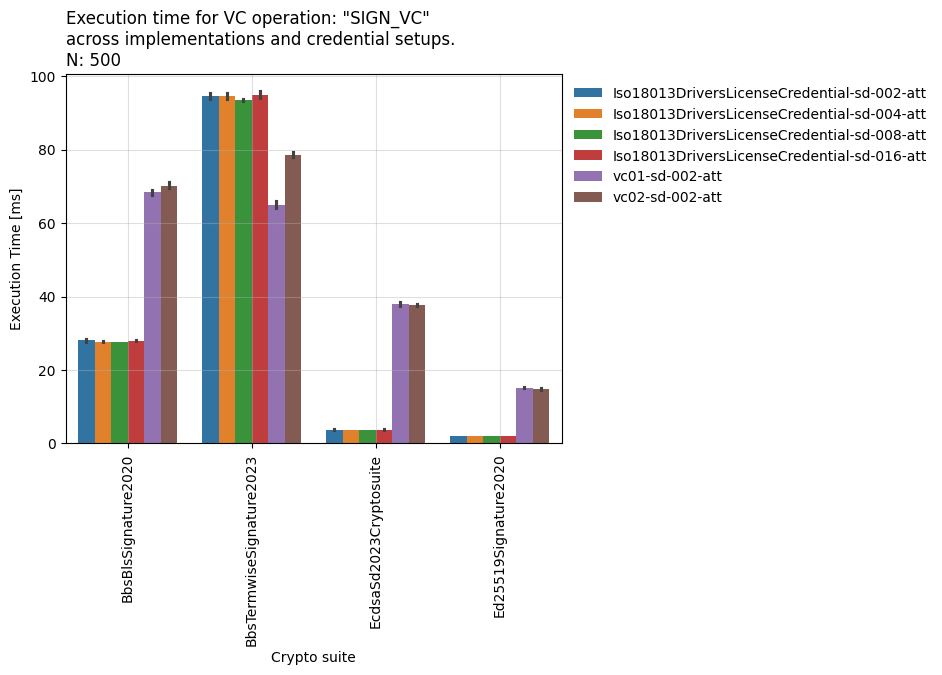

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


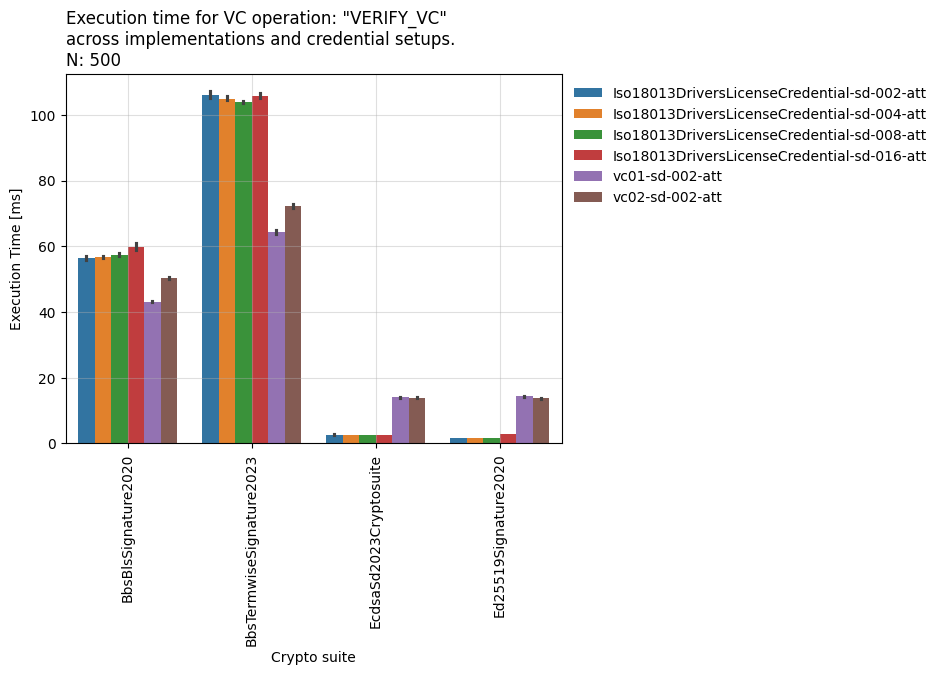

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


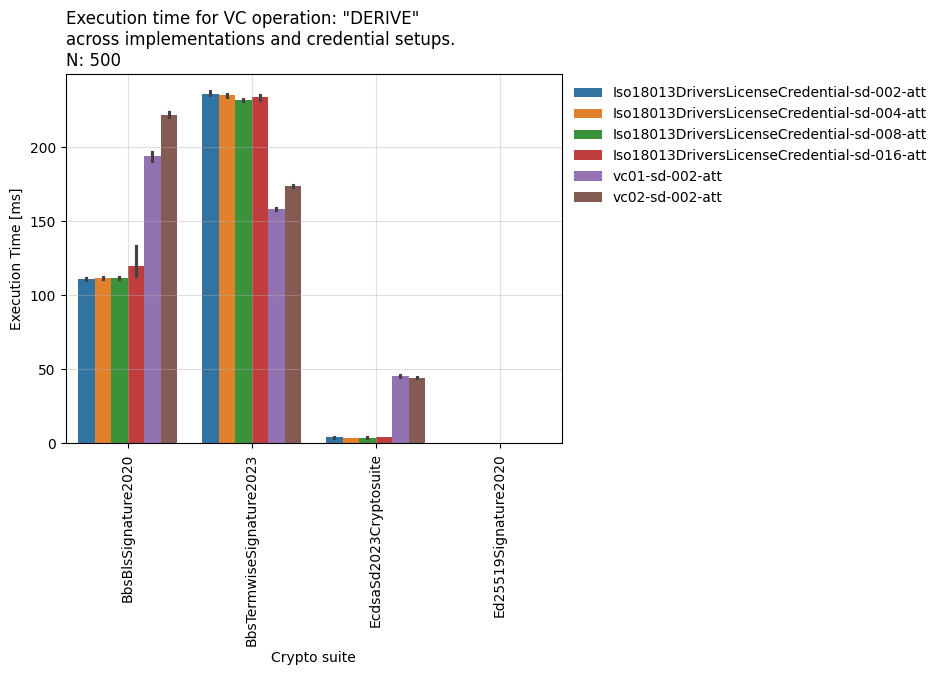

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


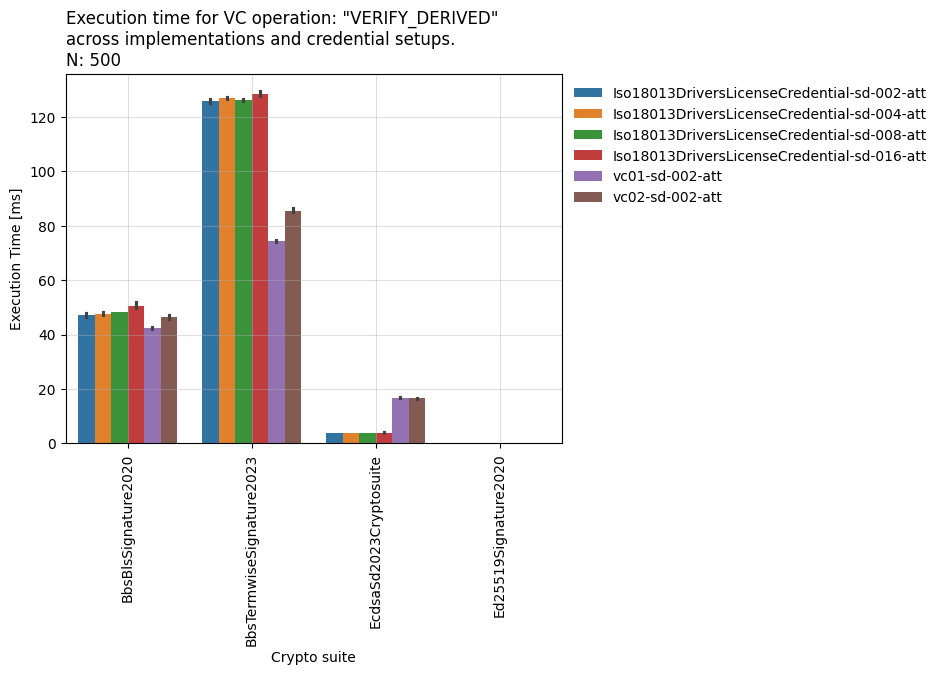

In [23]:
for step_i in STEPS:
    dfsb_step_i = dfsb[dfsb.step == step_i]
    ax = sns.barplot(
            data = dfsb_step_i,
            x = 'implementation',
            y = 'delta',
            hue = 'credentialSetupKey',
            order=implementation_order
        )
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time for VC operation: "{step_i}" \nacross implementations and credential setups.\nN: {N}''',loc='left')
    ax.set_xlabel('Crypto suite')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

---

### Considering every credential separately

In [24]:
cred = 'Iso18013DriversLicenseCredential'
assert cred in evaluated_credentials
print(f'Credential: {cred}')

Credential: Iso18013DriversLicenseCredential


In [25]:
dfsb_cred = dfsb[dfsb.credential == cred]
# Make sure we're dealing with exactly one credential
assert dfsb_cred.credential.unique().__len__() == 1

# Make sure that every implementation/credentialSetupKey/step has the same nr of records/measurements/values
assert dfsb_cred.groupby(['implementation', 'credentialSetupKey','step']).size().unique().__len__() == 1
n_iterations = dfsb_cred.groupby(['implementation', 'credentialSetupKey','step']).size().unique()[0]

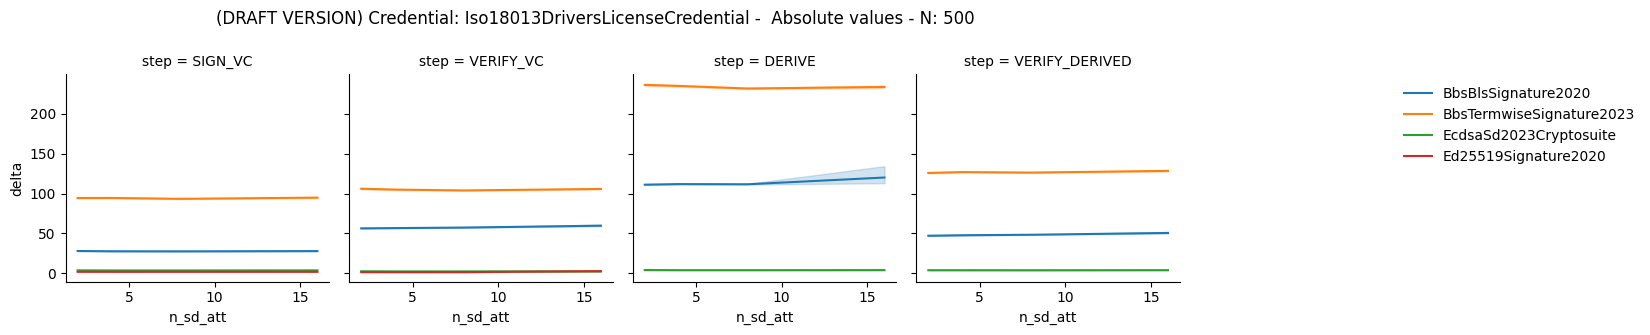

In [26]:
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    g = sns.FacetGrid(dfsb_cred, col='step', col_order=STEPS, sharey=True)
    g.map_dataframe(sns.lineplot,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',)
    
    g.axes.ravel()[0].legend(frameon=False, bbox_to_anchor=(6,1))
    #for ax in g.axes.ravel():
    #    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    #ax.legend(frameon=False, bbox_to_anchor=(2,1))
    plt.suptitle(f'(DRAFT VERSION) Credential: {cred} -  Absolute values - N: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/1559379516.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfsb_step_i = dfsb_cred[dfsb.step == step_i]


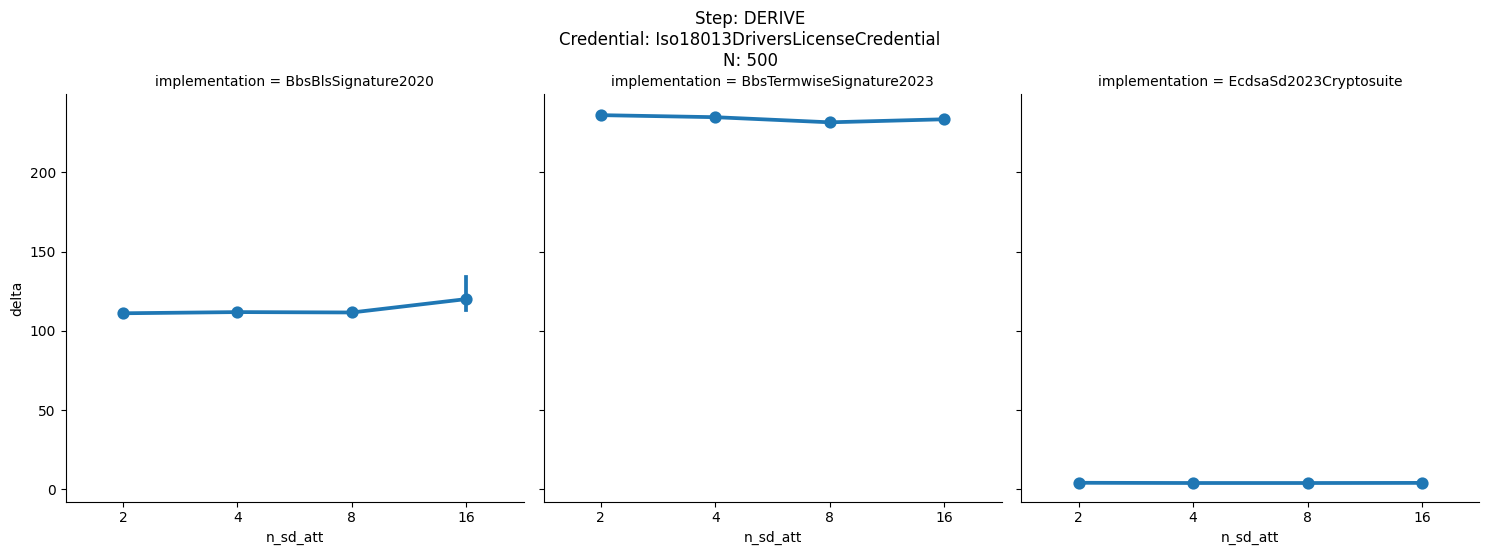

In [27]:
step_i = 'DERIVE'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=True
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}\nN: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2762483159.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfsb_step_i = dfsb_cred[dfsb.step == step_i]


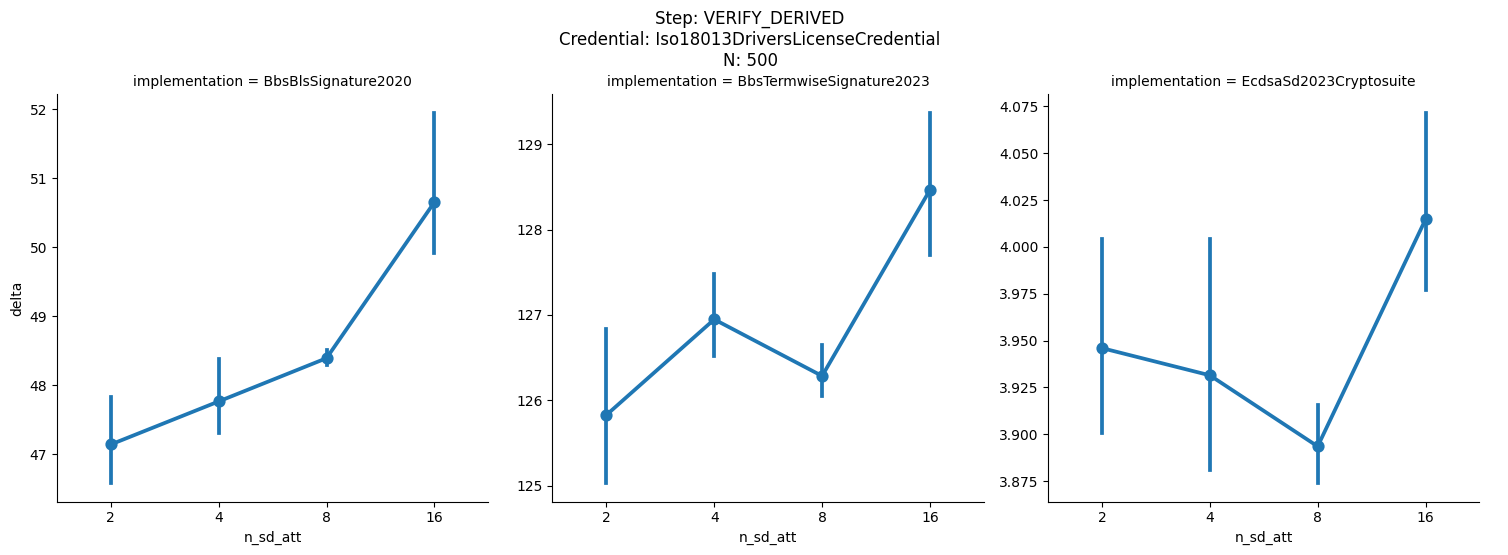

In [28]:
step_i = 'VERIFY_DERIVED'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=False
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}\nN: {n_iterations}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

In [29]:
fpath_records

'./data/records-202502070205.json'

---

In [30]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
#I.reset_index().credentialSetupKey.str.split('-sd-').apply(lambda x: x[0])
I['credentialSetupKey'] = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values

In [31]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
# To do this, we create the same credentialSetupKey for every -sd-\d{3} variant
new_credentialSetupKey_values = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values
I.reset_index(inplace=True)
I['credentialSetupKey'] = new_credentialSetupKey_values
display(I)

# Let's aggregate
I_agg = I.reset_index().groupby(['step', 'credentialSetupKey']).mean().drop('index',axis=1)
print('I_agg')
display(I_agg)

# Execution times for DERIVE and VERIFY_DERIVED must be kept as-is (i.e., separated per nr of disclosed attributes)
J = df_mean.stack().loc[['DERIVE','VERIFY_DERIVED']]
print('J')
display(J)

implementation,step,credentialSetupKey,BbsBlsSignature2020,BbsTermwiseSignature2023,EcdsaSd2023Cryptosuite,Ed25519Signature2020
0,SIGN_VC,Iso18013DriversLicenseCredential,28.05,94.47,3.77,1.98
1,SIGN_VC,Iso18013DriversLicenseCredential,27.69,94.51,3.66,1.93
2,SIGN_VC,Iso18013DriversLicenseCredential,27.59,93.41,3.64,1.94
3,SIGN_VC,Iso18013DriversLicenseCredential,27.91,94.91,3.77,1.94
4,SIGN_VC,vc01,68.33,65.01,37.87,15.15
5,SIGN_VC,vc02,70.17,78.60,37.60,14.75
6,VERIFY_VC,Iso18013DriversLicenseCredential,56.38,106.10,2.62,1.59
7,VERIFY_VC,Iso18013DriversLicenseCredential,56.74,104.99,2.50,1.56
8,VERIFY_VC,Iso18013DriversLicenseCredential,57.39,103.94,2.47,1.53
9,VERIFY_VC,Iso18013DriversLicenseCredential,59.78,105.79,2.52,2.78


I_agg


implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.8100   
          vc01                                          68.3300   
          vc02                                          70.1700   
VERIFY_VC Iso18013DriversLicenseCredential              57.5725   
          vc01                                          43.1200   
          vc02                                          50.2900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                    94.325   
          vc01                                                65.010   
          vc02                                                78.600   
VERIFY_VC Iso18013DriversLicenseCredential                   105.205   
          vc01                                                64.320   
          vc02                                                72.270   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7100   
          vc01                                             37.8700   
          vc02                                             37.6000   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5275   
          vc01                                             14.0500   
          vc02                                             13.9600   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                1.9475  
          vc01                                           15.1500  
          vc02                                           14.7500  
VERIFY_VC Iso18013DriversLicenseCredential                1.8650  
          vc01                                           14.3000  
          vc02                                           13.7500

J


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att               111.14   
               Iso18013DriversLicenseCredential-sd-004-att               111.89   
               Iso18013DriversLicenseCredential-sd-008-att               111.65   
               Iso18013DriversLicenseCredential-sd-016-att               120.11   
               vc01-sd-002-att                                           194.01   
               vc02-sd-002-att                                           221.96   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                47.14   
               Iso18013DriversLicenseCredential-sd-004-att                47.77   
               Iso18013DriversLicenseCredential-sd-008-att                48.39   
               Iso18013DriversLicenseCredential-sd-016-att                50.65   
               vc01-sd-002-att                                            42.50   
               vc02-sd-002-att                                            46.56   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    236.20   
               Iso18013DriversLicenseCredential-sd-004-att                    234.91   
               Iso18013DriversLicenseCredential-sd-008-att                    231.68   
               Iso18013DriversLicenseCredential-sd-016-att                    233.60   
               vc01-sd-002-att                                                158.13   
               vc02-sd-002-att                                                173.67   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    125.83   
               Iso18013DriversLicenseCredential-sd-004-att                    126.95   
               Iso18013DriversLicenseCredential-sd-008-att                    126.29   
               Iso18013DriversLicenseCredential-sd-016-att                    128.46   
               vc01-sd-002-att                                                 74.44   
               vc02-sd-002-att                                                 85.64   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    4.15   
               Iso18013DriversLicenseCredential-sd-004-att                    4.01   
               Iso18013DriversLicenseCredential-sd-008-att                    4.00   
               Iso18013DriversLicenseCredential-sd-016-att                    4.08   
               vc01-sd-002-att                                               45.58   
               vc02-sd-002-att                                               44.49   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    3.95   
               Iso18013DriversLicenseCredential-sd-004-att                    3.93   
               Iso18013DriversLicenseCredential-sd-008-att                    3.89   
               Iso18013DriversLicenseCredential-sd-016-att                    4.01   
               vc01-sd-002-att                                               16.80   
               vc02-sd-002-att                                               16.58   

implementation                                              Ed25519Signature2020  
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   NaN  
               Iso18013DriversLicenseCredential-sd-004-att                   NaN  
               Iso18013DriversLicenseCredential-sd-008-att         

In [32]:
I_agg

implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.8100   
          vc01                                          68.3300   
          vc02                                          70.1700   
VERIFY_VC Iso18013DriversLicenseCredential              57.5725   
          vc01                                          43.1200   
          vc02                                          50.2900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                    94.325   
          vc01                                                65.010   
          vc02                                                78.600   
VERIFY_VC Iso18013DriversLicenseCredential                   105.205   
          vc01                                                64.320   
          vc02                                                72.270   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7100   
          vc01                                             37.8700   
          vc02                                             37.6000   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5275   
          vc01                                             14.0500   
          vc02                                             13.9600   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                1.9475  
          vc01                                           15.1500  
          vc02                                           14.7500  
VERIFY_VC Iso18013DriversLicenseCredential                1.8650  
          vc01                                           14.3000  
          vc02                                           13.7500

In [33]:
# The concatenated result: K = I_agg & J
K = pd.concat([I_agg, J], axis=0)
K

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.8100   
               vc01                                                     68.3300   
               vc02                                                     70.1700   
VERIFY_VC      Iso18013DriversLicenseCredential                         57.5725   
               vc01                                                     43.1200   
               vc02                                                     50.2900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             111.1400   
               Iso18013DriversLicenseCredential-sd-004-att             111.8900   
               Iso18013DriversLicenseCredential-sd-008-att             111.6500   
               Iso18013DriversLicenseCredential-sd-016-att             120.1100   
               vc01-sd-002-att                                         194.0100   
               vc02-sd-002-att                                         221.9600   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              47.1400   
               Iso18013DriversLicenseCredential-sd-004-att              47.7700   
               Iso18013DriversLicenseCredential-sd-008-att              48.3900   
               Iso18013DriversLicenseCredential-sd-016-att              50.6500   
               vc01-sd-002-att                                          42.5000   
               vc02-sd-002-att                                          46.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                               94.325   
               vc01                                                           65.010   
               vc02                                                           78.600   
VERIFY_VC      Iso18013DriversLicenseCredential                              105.205   
               vc01                                                           64.320   
               vc02                                                           72.270   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   236.200   
               Iso18013DriversLicenseCredential-sd-004-att                   234.910   
               Iso18013DriversLicenseCredential-sd-008-att                   231.680   
               Iso18013DriversLicenseCredential-sd-016-att                   233.600   
               vc01-sd-002-att                                               158.130   
               vc02-sd-002-att                                               173.670   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                   125.830   
               Iso18013DriversLicenseCredential-sd-004-att                   126.950   
               Iso18013DriversLicenseCredential-sd-008-att                   126.290   
               Iso18013DriversLicenseCredential-sd-016-att                   128.460   
               vc01-sd-002-att                                                74.440   
               vc02-sd-002-att                                                85.640   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7100   
               vc01                                                        37.8700   
               vc02                                                        37.6000   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5275   
               vc01                                           

---

In [34]:
df_mean_stacked = K.copy()
print('df_mean_stacked.shape: ', df_mean_stacked.shape)
display(df_mean_stacked)
df_mean_stacked.round(2).to_clipboard()
print('df_mean_stacked was copied to clipboard!')

df_mean_stacked.shape:  (18, 4)


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.8100   
               vc01                                                     68.3300   
               vc02                                                     70.1700   
VERIFY_VC      Iso18013DriversLicenseCredential                         57.5725   
               vc01                                                     43.1200   
               vc02                                                     50.2900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             111.1400   
               Iso18013DriversLicenseCredential-sd-004-att             111.8900   
               Iso18013DriversLicenseCredential-sd-008-att             111.6500   
               Iso18013DriversLicenseCredential-sd-016-att             120.1100   
               vc01-sd-002-att                                         194.0100   
               vc02-sd-002-att                                         221.9600   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              47.1400   
               Iso18013DriversLicenseCredential-sd-004-att              47.7700   
               Iso18013DriversLicenseCredential-sd-008-att              48.3900   
               Iso18013DriversLicenseCredential-sd-016-att              50.6500   
               vc01-sd-002-att                                          42.5000   
               vc02-sd-002-att                                          46.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                               94.325   
               vc01                                                           65.010   
               vc02                                                           78.600   
VERIFY_VC      Iso18013DriversLicenseCredential                              105.205   
               vc01                                                           64.320   
               vc02                                                           72.270   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   236.200   
               Iso18013DriversLicenseCredential-sd-004-att                   234.910   
               Iso18013DriversLicenseCredential-sd-008-att                   231.680   
               Iso18013DriversLicenseCredential-sd-016-att                   233.600   
               vc01-sd-002-att                                               158.130   
               vc02-sd-002-att                                               173.670   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                   125.830   
               Iso18013DriversLicenseCredential-sd-004-att                   126.950   
               Iso18013DriversLicenseCredential-sd-008-att                   126.290   
               Iso18013DriversLicenseCredential-sd-016-att                   128.460   
               vc01-sd-002-att                                                74.440   
               vc02-sd-002-att                                                85.640   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7100   
               vc01                                                        37.8700   
               vc02                                                        37.6000   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5275   
               vc01                                           

df_mean_stacked was copied to clipboard!


Relative performance results.

In [35]:
# relative to col
rel2c = 'EcdsaSd2023Cryptosuite'

In [36]:
# Compute relative performance
A = df_mean_stacked.values
B = df_mean_stacked[rel2c].values
C = (A.T / B).T
# df_C contains the performance values
df_C = pd.DataFrame(
    data=C,
    index=df_mean_stacked.index,
    columns=df_mean_stacked.columns
)
display(df_C.round(2))
df_C.round(2).to_clipboard()

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                            7.50   
               vc01                                                        1.80   
               vc02                                                        1.87   
VERIFY_VC      Iso18013DriversLicenseCredential                           22.78   
               vc01                                                        3.07   
               vc02                                                        3.60   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                26.78   
               Iso18013DriversLicenseCredential-sd-004-att                27.90   
               Iso18013DriversLicenseCredential-sd-008-att                27.91   
               Iso18013DriversLicenseCredential-sd-016-att                29.44   
               vc01-sd-002-att                                             4.26   
               vc02-sd-002-att                                             4.99   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                11.93   
               Iso18013DriversLicenseCredential-sd-004-att                12.16   
               Iso18013DriversLicenseCredential-sd-008-att                12.44   
               Iso18013DriversLicenseCredential-sd-016-att                12.63   
               vc01-sd-002-att                                             2.53   
               vc02-sd-002-att                                             2.81   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                                25.42   
               vc01                                                             1.72   
               vc02                                                             2.09   
VERIFY_VC      Iso18013DriversLicenseCredential                                41.62   
               vc01                                                             4.58   
               vc02                                                             5.18   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                     56.92   
               Iso18013DriversLicenseCredential-sd-004-att                     58.58   
               Iso18013DriversLicenseCredential-sd-008-att                     57.92   
               Iso18013DriversLicenseCredential-sd-016-att                     57.25   
               vc01-sd-002-att                                                  3.47   
               vc02-sd-002-att                                                  3.90   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                     31.86   
               Iso18013DriversLicenseCredential-sd-004-att                     32.30   
               Iso18013DriversLicenseCredential-sd-008-att                     32.47   
               Iso18013DriversLicenseCredential-sd-016-att                     32.03   
               vc01-sd-002-att                                                  4.43   
               vc02-sd-002-att                                                  5.17   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                                1.0   
               vc01                                                            1.0   
               vc02                                                            1.0   
VERIFY_VC      Iso18013DriversLicenseCredential                                1.0   
               vc01                                           

In [37]:
df_C.to_clipboard()

---

## Results (transformed and scaled)

### `dfa`

In [40]:
dfa.reset_index().credentialSetupKey.value_counts(dropna=False)

vc01-sd-002-att                                14000
vc02-sd-002-att                                14000
Iso18013DriversLicenseCredential-sd-002-att    14000
Iso18013DriversLicenseCredential-sd-004-att    14000
Iso18013DriversLicenseCredential-sd-008-att    14000
Iso18013DriversLicenseCredential-sd-016-att    14000
Name: credentialSetupKey, dtype: int64

In [41]:
dfa_w = dfa.unstack(['implementation', 'credentialSetupKey', 'stepType'])
display(dfa_w.head(3))
dfa_w.shape

nrCredentialSubjectAttributes       \
implementation                     BbsBlsSignature2020        
credentialSetupKey                     vc01-sd-002-att        
stepType                                         START  END   
iteration step                                                
0         DERIVE                                   3.0  3.0   
          SIGN_VC                                  3.0  3.0   
          VERIFY_DERIVED                           3.0  3.0   

                                                                             \
implementation           BbsTermwiseSignature2023      Ed25519Signature2020   
credentialSetupKey                vc01-sd-002-att           vc01-sd-002-att   
stepType                                    START  END                START   
iteration step                                                                
0         DERIVE                              3.0  3.0                  NaN   
          SIGN_VC                             3.0  3.0                  3.0   
          VERIFY_DERIVED                      3.0  3.0                  NaN   

                                                                               \
implementation                EcdsaSd2023Cryptosuite      BbsBlsSignature2020   
credentialSetupKey                   vc01-sd-002-att          vc02-sd-002-att   
stepType                  END                  START  END               START   
iteration step                                                                  
0         DERIVE          NaN                    3.0  3.0                10.0   
          SIGN_VC         3.0                    3.0  3.0                10.0   
          VERIFY_DERIVED  NaN                    3.0  3.0                10.0   

                                ...  \
implementation                  ...   
credentialSetupKey              ...   
stepType                   END  ...   
iteration step                  ...   
0         DERIVE          10.0  ...   
          SIGN_VC         10.0  ...   
          VERIFY_DERIVED  10.0  ...   

                                                           startTime  \
implementation                                EcdsaSd2023Cryptosuite   
credentialSetupKey       Iso18013DriversLicenseCredential-sd-008-att   
stepType                                                       START   
iteration step                                                         
0         DERIVE                                        1.790174e+06   
          SIGN_VC                                       1.790167e+06   
          VERIFY_DERIVED                                1.790179e+06   

                                        \
implementation                           
credentialSetupKey                       
stepType                           END   
iteration step                           
0         DERIVE          1.790179e+06   
          SIGN_VC         1.790171e+06   
          VERIFY_DERIVED  1.790183e+06   

                                                                      \
implementation                                   BbsBlsSignature2020   
credentialSetupKey       Iso18013DriversLicenseCredential-sd-016-att   
stepType                                                       START   
iteration step                                                         
0         DERIVE                                        2.204996e+06   
          SIGN_VC                                       2.204911e+06   
          VERIFY_DERIVED                                2.205114e+06   

                                        \
implementation                           
credentialSetupKey                       
stepType                           END   
iteration step                           
0         DERIVE          2.205113e+06   
          SIGN_VC         2.204938e+06   
          VERIFY_DERIVED  2.205172e+06   

                                                                      \
implementation           

(2000, 144)

In [42]:
# dfa_w01: Only SIGN and VERIFY steps
dfa_w01 = dfa_w.drop(['DERIVE', 'VERIFY_DERIVED'], level=1)
# dfa_w02: Only DERIVE and VERIFY_DERIVED steps
dfa_w02 = dfa_w.drop(['SIGN_VC', 'VERIFY_VC'], level=1)

In [43]:
dfa_w01

nrCredentialSubjectAttributes       \
implementation                BbsBlsSignature2020        
credentialSetupKey                vc01-sd-002-att        
stepType                                    START  END   
iteration step                                           
0         SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
1         SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
2         SIGN_VC                             3.0  3.0   
...                                           ...  ...   
497       VERIFY_VC                           3.0  3.0   
498       SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
499       SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   

                                                                             \
implementation      BbsTermwiseSignature2023      Ed25519Signature2020        
credentialSetupKey           vc01-sd-002-att           vc01-sd-002-att        
stepType                               START  END                START  END   
iteration step                                                                
0         SIGN_VC                        3.0  3.0                  3.0  3.0   
          VERIFY_VC                      3.0  3.0                  3.0  3.0   
1         SIGN_VC                        3.0  3.0                  3.0  3.0   
          VERIFY_VC                      3.0  3.0                  3.0  3.0   
2         SIGN_VC                        3.0  3.0                  3.0  3.0   
...                                      ...  ...                  ...  ...   
497       VERIFY_VC                      3.0  3.0                  3.0  3.0   
498       SIGN_VC                        3.0  3.0                  3.0  3.0   
          VERIFY_VC                      3.0  3.0                  3.0  3.0   
499       SIGN_VC                        3.0  3.0                  3.0  3.0   
          VERIFY_VC                      3.0  3.0                  3.0  3.0   

                                                                           \
implementation      EcdsaSd2023Cryptosuite      BbsBlsSignature2020         
credentialSetupKey         vc01-sd-002-att          vc02-sd-002-att         
stepType                             START  END               START   END   
iteration step                                                              
0         SIGN_VC                      3.0  3.0                10.0  10.0   
          VERIFY_VC                    3.0  3.0                10.0  10.0   
1         SIGN_VC                      3.0  3.0                10.0  10.0   
          VERIFY_VC                    3.0  3.0                10.0  10.0   
2         SIGN_VC                      3.0  3.0                10.0  10.0   
...                                    ...  ...                 ...   ...   
497       VERIFY_VC                    3.0  3.0                10.0  10.0   
498       SIGN_VC                      3.0  3.0                10.0  10.0   
          VERIFY_VC                    3.0  3.0                10.0  10.0   
499       SIGN_VC                      3.0  3.0                10.0  10.0   
          VERIFY_VC                    3.0  3.0                10.0  10.0   

                     ...                                   startTime  \
implementation       ...                      EcdsaSd2023Cryptosuite   
credentialSetupKey   ... Iso18013DriversLicenseCredential-sd-008-att   
stepType             ...                                       START   
iteration step       ...                                               
0         SIGN_VC    ...                                1.790167e+06   
          VERIFY_VC  ...                                1.790171e+06   
1         SIGN_VC    ...                                1.790999e+06   
          VERIFY_

In [44]:
def scale(df: pd.DataFrame) -> pd.DataFrame:
    sclr = skp.StandardScaler()
    return pd.DataFrame(
        data = sclr.fit_transform(df),
        columns = df.columns,
        index = df.index
    )
def add_delta_col(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.stack([0,1,2])
    tmp = (tmp.END - tmp.START).droplevel(level=2).rename('delta')
    return tmp.reset_index()

def add_credential_col(df: pd.DataFrame) -> pd.DataFrame:
    df['credential'] = pd.Series(df.credentialSetupKey.str.split('-sd-').apply(lambda x: x[0]).values)
    return df

def add_n_sd_att_col(df: pd.DataFrame) -> pd.DataFrame:
    df['n_sd_att'] = df.credentialSetupKey.apply(extract_nr_of_sd_attributes)
    return df

def run_preprocessing_steps(df: pd.DataFrame) -> pd.DataFrame:
    df_scld = scale(df)
    df_scld = add_delta_col(df_scld)
    df_scld = add_credential_col(df_scld)
    df_scld = add_n_sd_att_col(df_scld)
    return df_scld

In [45]:
dfsb_dfa_w01 = run_preprocessing_steps(dfa_w01)
dfsb_dfa_w02 = run_preprocessing_steps(dfa_w02)

/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [46]:
dfsb_dfa_w01[
    (dfsb_dfa_w01.implementation == 'BbsBlsSignature2020')&
    (dfsb_dfa_w01.step == 'SIGN_VC')&
    (dfsb_dfa_w01.credential == 'Iso18013DriversLicenseCredential')
].delta.describe()

count    6000.000000
mean       -0.000041
std         0.000059
min        -0.000142
25%        -0.000120
50%         0.000000
75%         0.000000
max         0.000415
Name: delta, dtype: float64

SIGN AND VERIFY

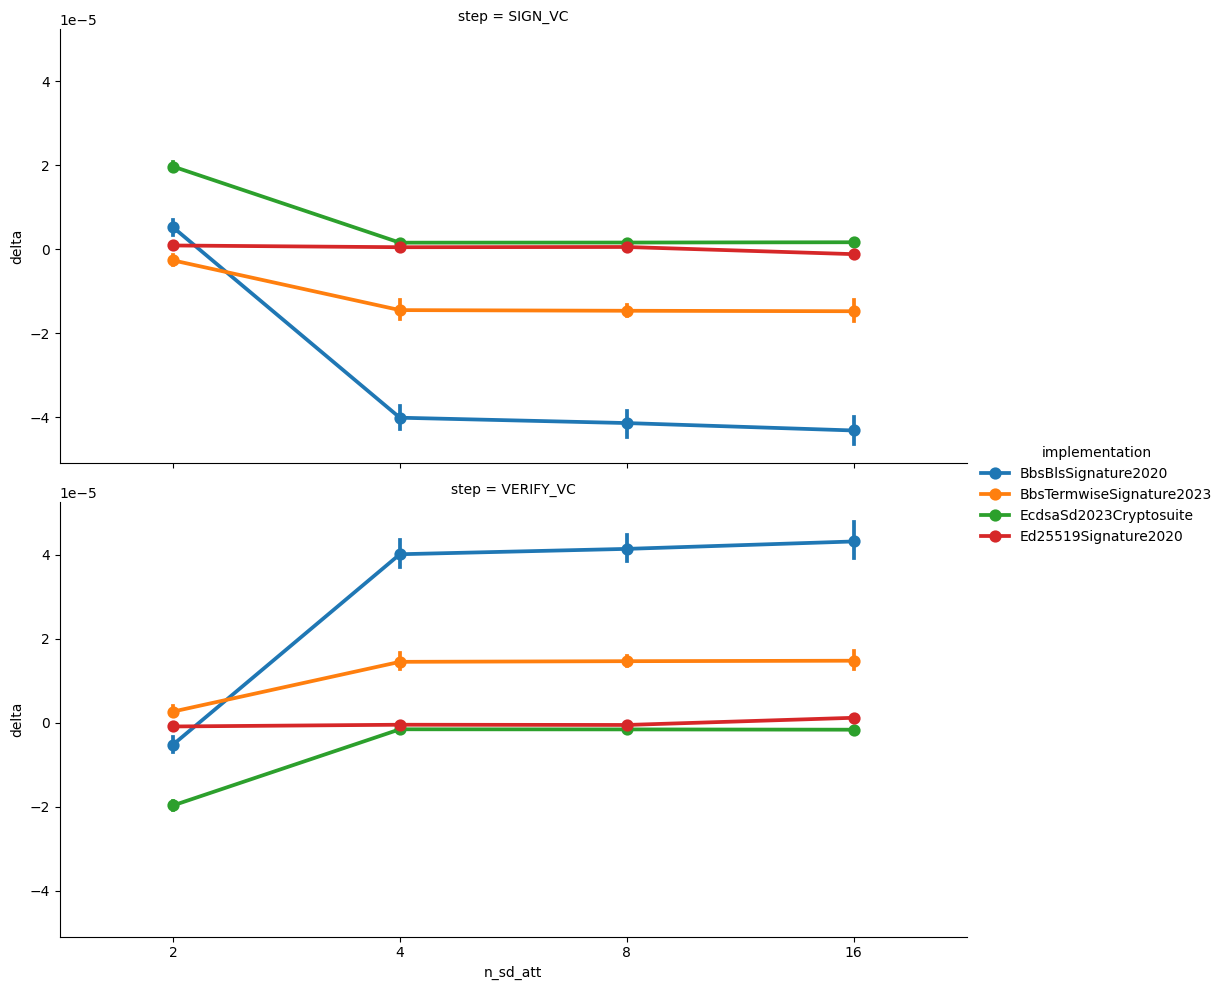

In [47]:
# SIGN AND VERIFY
snsdata = dfsb_dfa_w01.copy()
g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',
        row = 'step',
        row_order = ['SIGN_VC', 'VERIFY_VC'],
        kind = 'point',
        aspect=2,
        sharey=True
    )

DERIVE & VERIFY_DERIVED

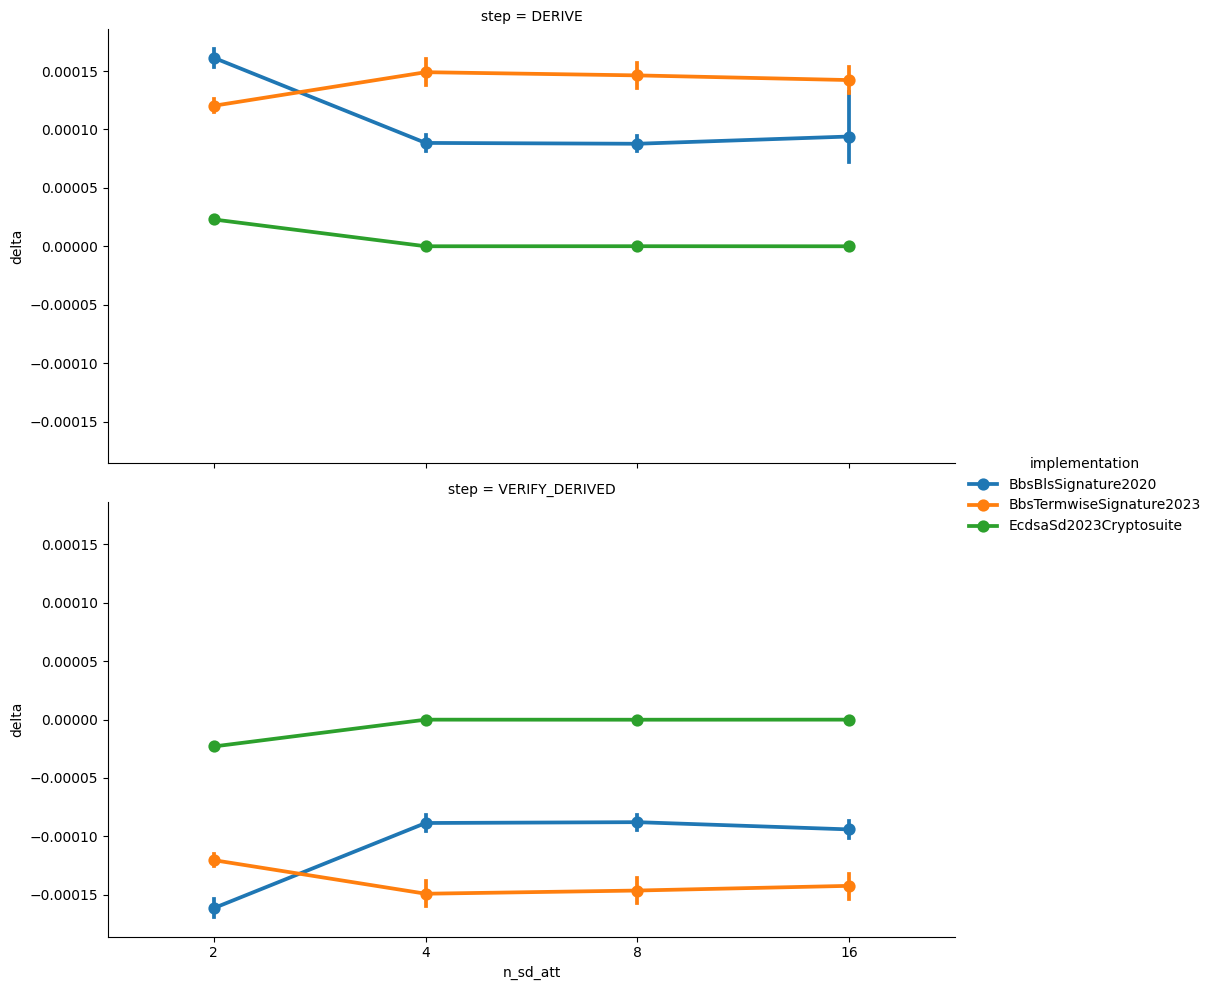

In [48]:
# DERIVE & VERIFY_DERIVED

snsdata = dfsb_dfa_w02.copy()

g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        row = 'step',
        row_order = ['DERIVE', 'VERIFY_DERIVED'],
        hue = 'implementation',
        kind = 'point',
        aspect=2,
        sharey=True
    )

### `dfb`

In [49]:
display(get_df_meta())

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2359744582.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,Iso18013DriversLicenseCredential-sd-002-att,21,2,19
1,Iso18013DriversLicenseCredential-sd-004-att,21,4,17
2,Iso18013DriversLicenseCredential-sd-008-att,21,8,13
3,Iso18013DriversLicenseCredential-sd-016-att,21,16,5
4,vc01-sd-002-att,3,2,1
5,vc02-sd-002-att,10,2,8


In [50]:
dfb = df_delta.unstack(['step','credentialSetupKey']).delta

### VC operation subsets

We consider the following VC operation subsets:
- ['SIGN_VC', 'VERIFY_VC']: these columns strictly contain numeric values for every implementation.
- ['DERIVE', 'VERIFY_DERIVED']: these columns only contain numeric values for implementations that support selective disclosure. An implementation that does not support selective disclosure would have NaN values for these columns. You cannot feed NaN values into a scaler without imputing them. However, there's no reason to impute these values. Hence, the separation.

In [63]:
b_01_cols = ['SIGN_VC', 'VERIFY_VC']
b_02_cols = ['DERIVE', 'VERIFY_DERIVED']
col_order = b_01_cols + b_02_cols

In [67]:
# Create subsets
dfb_01 = dfb[b_01_cols]
dfb_02 = dfb[b_02_cols]

# Log-transform
dfb_01 = dfb_01.apply(np.log)
dfb_02 = dfb_02.apply(np.log)

dfb_01.shape, dfb_02.shape

((2000, 12), (2000, 12))

Scale subsets

In [54]:
dfb_01_scld = scale(dfb_01)
dfb_02_scld = scale(dfb_02)

Preprocess the subset dataframes into a form and shape that seaborn wants.

In [55]:
snsdata_b01 = dfb_01_scld.stack([0,1]).rename('delta_scld').reset_index()
snsdata_b02 = dfb_02_scld.stack([0,1]).rename('delta_scld').reset_index()
# preprocessing
snsdata_b01 = add_credential_col(snsdata_b01)
snsdata_b01 = add_n_sd_att_col(snsdata_b01)
snsdata_b02 = add_credential_col(snsdata_b02)
snsdata_b02 = add_n_sd_att_col(snsdata_b02)

### Merge with meta dataframe

Merge with **meta dataframe**.

Note: the meta dataframe's `nrHiddenCredentialSubjectAttributes` is expected to equal `n_sd_att`.</br>
The only difference is that the former was computed while the latter was extracted from the filename.

In [56]:
snsdata = pd.concat([snsdata_b01, snsdata_b02],axis=0)\
            .merge(get_df_meta(), on='credentialSetupKey')

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2359744582.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


In [68]:
class CatplotConfiguration:
    x: str
    y: str
    kwargs_common: dict
    
    def __init__(self, 
                 x: str,
                 y: str,
                 kwargs_common: dict,
                 suptitle: str
                ):
        self.x = x
        self.y = y
        self.kwargs_common = kwargs_common
        self.suptitle = suptitle
        
    def create_plot(self) -> sns.FacetGrid:
        g = sns.catplot(
            x=self.x,
            y=self.y,
            **kwargs_catplot_common)

        col_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
        for axi, (ti_idx, ti) in zip(g.axes.flat, enumerate(col_order)):
            axi.set_title(f'{ti_idx+1:1d}) {ti}')

        g.figure.suptitle(self.suptitle, size=14)
        g.figure.subplots_adjust(top=.9)
        return g


Three catplots will be created:
1. `nrDisclosedCredentialSubjectAttributes` on `delta_scld`
2. `nrHiddenCredentialSubjectAttributes` on `delta_scld`
3. `nrCredentialSubjectAttributes` on `delta_scld`

In [69]:
# parameters that apply to all three plots
kwargs_catplot_common = dict(
    data = snsdata,
    hue = 'implementation',
    col = 'step',
    col_order = col_order,
    col_wrap = 2,
    kind = 'point',
    height=3,
    aspect=2,
    sharey=True,
    palette="tab20c"
)

catplot_configurations = [
    CatplotConfiguration('nrDisclosedCredentialSubjectAttributes', 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over nr. of disclosed attributes"),
    CatplotConfiguration('nrHiddenCredentialSubjectAttributes', 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over nr. of disclosed attributes"),
    CatplotConfiguration('nrCredentialSubjectAttributes', 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over nr. of disclosed attributes")
]

In [70]:
cpc01, cpc02, cpc03 = catplot_configurations

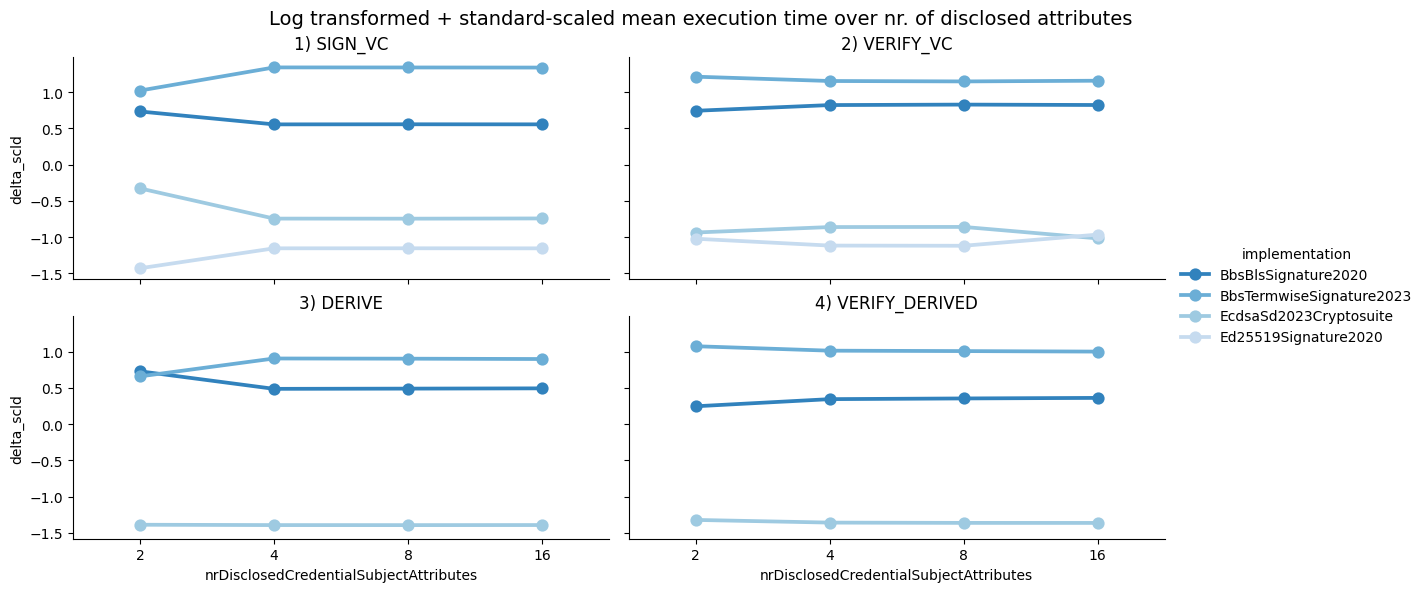

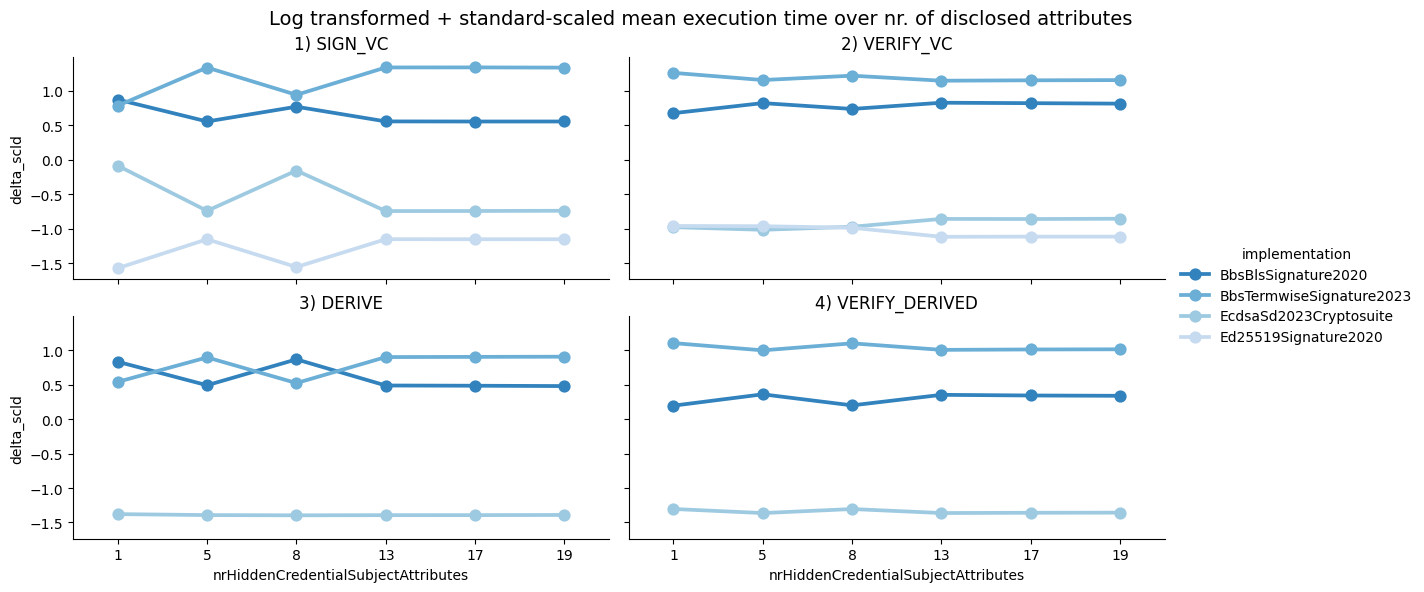

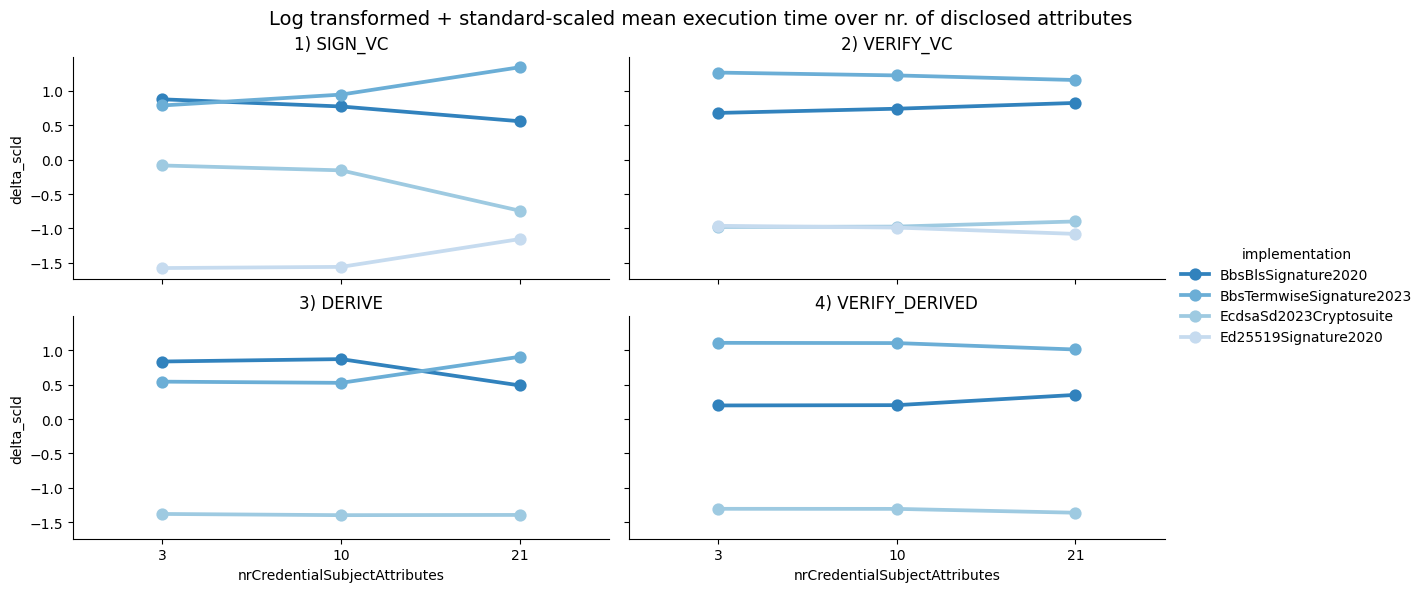

In [60]:
###########################
# 01
# vs. nr of disclosed attributes
fname_catplot_01 = 'std-scaled-mean-execution-time-vs-nrDisclosedCredentialSubjectAttributes.png'
g01 = cpc01.create_plot()
g01.savefig(fname_catplot_01)

###########################
# 02
# vs nr. hidden attributes
fname_catplot_02 = 'std-scaled-mean-execution-time-vs-nrHiddenCredentialSubjectAttributes.png'
g02 = cpc02.create_plot()
g02.savefig(fname_catplot_02)

###########################
# 03
# vs nr. total attributes
fname_catplot_03 = 'std-scaled-mean-execution-time-vs-nrCredentialSubjectAttributes.png'
g03 = cpc03.create_plot()
g03.savefig(fname_catplot_03)

Create overview table (input: log-transformed & std-scaled data)

In [71]:
df_ov = pd.concat([snsdata_b01, snsdata_b02],axis=0).groupby(['implementation','step','n_sd_att'])['delta_scld'].mean()
df_ov = df_ov.unstack('implementation').loc[step_order]
df_ov.round(2).to_clipboard()
df_ov

implementation           BbsBlsSignature2020  BbsTermwiseSignature2023  \
step           n_sd_att                                                  
SIGN_VC        2                    0.734037                  1.022593   
               4                    0.556037                  1.342072   
               8                    0.557414                  1.341304   
               16                   0.556411                  1.339917   
VERIFY_VC      2                    0.743751                  1.214123   
               4                    0.822496                  1.154478   
               8                    0.828991                  1.148718   
               16                   0.823401                  1.158496   
DERIVE         2                    0.729024                  0.659051   
               4                    0.486930                  0.905950   
               8                    0.490168                  0.903159   
               16                   0.493785                  0.898506   
VERIFY_DERIVED 2                    0.246493                  1.075041   
               4                    0.344981                  1.013605   
               8                    0.354632                  1.007897   
               16                   0.362140                  1.000944   

implementation           EcdsaSd2023Cryptosuite  Ed25519Signature2020  
step           n_sd_att                                                
SIGN_VC        2                      -0.327453             -1.429177  
               4                      -0.743971             -1.154138  
               8                      -0.745059             -1.153659  
               16                     -0.741765             -1.154563  
VERIFY_VC      2                      -0.936024             -1.021849  
               4                      -0.860647             -1.116327  
               8                      -0.858941             -1.118768  
               16                     -1.017099             -0.964798  
DERIVE         2                      -1.388075                   NaN  
               4                      -1.392880                   NaN  
               8                      -1.393327                   NaN  
               16                     -1.392290                   NaN  
VERIFY_DERIVED 2                      -1.321534                   NaN  
               4                      -1.358586                   NaN  
               8                      -1.362529                   NaN  
               16                     -1.363084                   NaN

## Results (absolute)

Create overview table (input: raw/absolute data)

ndex(['implementation', 'iteration', 'step', 'credentialSetupKey',
       'delta_scld', 'credential', 'n_sd_att', 'nrCredentialSubjectAttributes',
       'nrDisclosedCredentialSubjectAttributes',
       'nrHiddenCredentialSubjectAttributes'],
      dtype='object')


agg showing mean for the subsets ['step', and
- [ ] n_sd_att (=nrDisclosedCredentialSubjectAttributes)
- [ ] nrHiddenCredentialSubjectAttributes
- [ ] nrCredentialSubjectAttributes (i.e., the total number of attributes)

,iteration,step,credentialSetupKey,BbsBlsSignature2020,BbsTermwiseSignature2023,EcdsaSd2023Cryptosuite,Ed25519Signature2020,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes,credential
0,0,DERIVE,Iso18013DriversLicenseCredential-sd-002-att,140.345167,237.693459,4.664292,NaN,21,2,19,Iso18013DriversLicenseCredential
1,0,SIGN_VC,Iso18013DriversLicenseCredential-sd-002-att,29.077417,102.599833,4.952208,2.423125,21,2,19,Iso18013DriversLicenseCredential
2,0,VERIFY_DERIVED,Iso18013DriversLicenseCredential-sd-002-att,46.609083,126.190708,4.316083,NaN,21,2,19,Iso18013DriversLicenseCredential
3,0,VERIFY_VC,Iso18013DriversLicenseCredential-sd-002-att,56.845541,105.928167,2.594083,1.740000,21,2,19,Iso18013DriversLicenseCredential
4,1,DERIVE,Iso18013DriversLicenseCredential-sd-002-att,133.933666,233.665250,4.509583,NaN,21,2,19,Iso18013DriversLicenseCredential
...,...,...,...,...,...,...,...,...,...,...,...
11995,498,VERIFY_VC,vc02-sd-002-att,48.782500,70.862500,13.992250,13.133458,10,2,8,vc02
11996,499,DERIVE,vc02-sd-002-att,232.199166,170.146167,42.578125,NaN,10,2,8,vc02
11997,499,SIGN_VC,vc02-sd-002-att,67.648875,76.640542,37.628375,13.116625,10,2,8,vc02
11998,499,VERIFY_DERIVED,vc02-sd-002-att,46.402625,85.626166,16.249416,NaN,10,2,8,vc02


In [84]:
print(list(get_df_meta().columns))

['credentialSetupKey', 'nrCredentialSubjectAttributes', 'nrDisclosedCredentialSubjectAttributes', 'nrHiddenCredentialSubjectAttributes']


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2359744582.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


In [86]:
 dfb.stack(['step','credentialSetupKey']).unstack(['implementation'])

implementation                                                   BbsBlsSignature2020  \
iteration step      credentialSetupKey                                                 
0         DERIVE    Iso18013DriversLicenseCredential-sd-002-att           140.345167   
                    Iso18013DriversLicenseCredential-sd-004-att           119.402666   
                    Iso18013DriversLicenseCredential-sd-008-att           120.488291   
                    Iso18013DriversLicenseCredential-sd-016-att           117.288208   
                    vc01-sd-002-att                                       173.457541   
...                                                                              ...   
499       VERIFY_VC Iso18013DriversLicenseCredential-sd-004-att            58.186709   
                    Iso18013DriversLicenseCredential-sd-008-att            56.961292   
                    Iso18013DriversLicenseCredential-sd-016-att            58.871750   
                    vc01-sd-002-att                                        45.944750   
                    vc02-sd-002-att                                        51.988958   

implementation                                                   BbsTermwiseSignature2023  \
iteration step      credentialSetupKey                                                      
0         DERIVE    Iso18013DriversLicenseCredential-sd-002-att                237.693459   
                    Iso18013DriversLicenseCredential-sd-004-att                233.663542   
                    Iso18013DriversLicenseCredential-sd-008-att                232.845458   
                    Iso18013DriversLicenseCredential-sd-016-att                227.977333   
                    vc01-sd-002-att                                            174.401958   
...                                                                                   ...   
499       VERIFY_VC Iso18013DriversLicenseCredential-sd-004-att                104.544083   
                    Iso18013DriversLicenseCredential-sd-008-att                103.388417   
                    Iso18013DriversLicenseCredential-sd-016-att                104.576250   
                    vc01-sd-002-att                                             63.328459   
                    vc02-sd-002-att                                             70.337708   

implementation                                                   EcdsaSd2023Cryptosuite  \
iteration step      credentialSetupKey                                                    
0         DERIVE    Iso18013DriversLicenseCredential-sd-002-att                4.664292   
                    Iso18013DriversLicenseCredential-sd-004-att                4.053541   
                    Iso18013DriversLicenseCredential-sd-008-att                4.376458   
                    Iso18013DriversLicenseCredential-sd-016-att                3.794083   
                    vc01-sd-002-att                                           53.970583   
...                                                                                 ...   
499       VERIFY_VC Iso18013DriversLicenseCredential-sd-004-att                2.365958   
                    Iso18013DriversLicenseCredential-sd-008-att                2.559625   
                    Iso18013DriversLicenseCredential-sd-016-att                2.422375   
                    vc01-sd-002-att                                           13.904459   
                    vc02-sd-002-att                                           13.067708   

implementation                                                   Ed25519Signature2020  
iteration step      credentialSetupKey                                                 
0         DERIVE    Iso18013DriversLicenseCredential-sd-002-att                   NaN  
                    Iso18013DriversLicenseCredential-sd-004-att                   NaN  
                    Iso18013DriversLicenseCredential-sd-008-att                   NaN  
                    I

In [103]:
df_abs = dfb.stack('credentialSetupKey')
df_abs = df_abs.stack().rename('mean_delta').reset_index()
# merge with meta dataframe
df_abs = df_abs.merge(get_df_meta(), on='credentialSetupKey')
df_abs

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_11992/2359744582.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


,implementation,iteration,credentialSetupKey,step,mean_delta,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,BbsBlsSignature2020,0,Iso18013DriversLicenseCredential-sd-002-att,DERIVE,140.345167,21,2,19
1,BbsBlsSignature2020,0,Iso18013DriversLicenseCredential-sd-002-att,SIGN_VC,29.077417,21,2,19
2,BbsBlsSignature2020,0,Iso18013DriversLicenseCredential-sd-002-att,VERIFY_DERIVED,46.609083,21,2,19
3,BbsBlsSignature2020,0,Iso18013DriversLicenseCredential-sd-002-att,VERIFY_VC,56.845541,21,2,19
4,BbsBlsSignature2020,1,Iso18013DriversLicenseCredential-sd-002-att,DERIVE,133.933666,21,2,19
...,...,...,...,...,...,...,...,...
41995,Ed25519Signature2020,497,vc02-sd-002-att,VERIFY_VC,14.060084,10,2,8
41996,Ed25519Signature2020,498,vc02-sd-002-att,SIGN_VC,13.724750,10,2,8
41997,Ed25519Signature2020,498,vc02-sd-002-att,VERIFY_VC,13.133458,10,2,8
41998,Ed25519Signature2020,499,vc02-sd-002-att,SIGN_VC,13.116625,10,2,8


In [129]:
# gci: group col <i>
gci = 'nrDisclosedCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_01 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_01

implementation                                         BbsBlsSignature2020  \
step           nrDisclosedCredentialSubjectAttributes                        
SIGN_VC        2                                                 55.515669   
               4                                                 27.692123   
               8                                                 27.593774   
               16                                                27.911911   
VERIFY_VC      2                                                 49.931208   
               4                                                 56.735878   
               8                                                 57.394784   
               16                                                59.782621   
DERIVE         2                                                175.705054   
               4                                                111.887995   
               8                                                111.646258   
               16                                               120.108685   
VERIFY_DERIVED 2                                                 45.398887   
               4                                                 47.766078   
               8                                                 48.392291   
               16                                                50.650798   

implementation                                         BbsTermwiseSignature2023  \
step           nrDisclosedCredentialSubjectAttributes                             
SIGN_VC        2                                                      79.359759   
               4                                                      94.508885   
               8                                                      93.408156   
               16                                                     94.906709   
VERIFY_VC      2                                                      80.894696   
               4                                                     104.990368   
               8                                                     103.942384   
               16                                                    105.793902   
DERIVE         2                                                     189.333092   
               4                                                     234.910396   
               8                                                     231.675560   
               16                                                    233.598811   
VERIFY_DERIVED 2                                                      95.305370   
               4                                                     126.948679   
               8                                                     126.286041   
               16                                                    128.463950   

implementation                                         EcdsaSd2023Cryptosuite  \
step           nrDisclosedCredentialSubjectAttributes                           
SIGN_VC        2                                                    26.412928   
               4                                                     3.655697   
               8                                                     3.643752   
               16                                                    3.772889   
VERIFY_VC      2                                                    10.206665   
               4                                                     2.499205   
               8                                                     2.473457   
               16                                                    2.522409   
DERIVE         2                                                    31.403919   
               4                                                     4.007795   
               8                                                     4.001495   
               16                              

In [130]:
# gci: group col <i>
gci = 'nrHiddenCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_02 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_02

implementation                                      BbsBlsSignature2020  \
step           nrHiddenCredentialSubjectAttributes                        
SIGN_VC        1                                              68.331896   
               5                                              27.911911   
               8                                              70.168121   
               13                                             27.593774   
               17                                             27.692123   
               19                                             28.046988   
VERIFY_VC      1                                              43.116789   
               5                                              59.782621   
               8                                              50.292959   
               13                                             57.394784   
               17                                             56.735878   
               19                                             56.383875   
DERIVE         1                                             194.008249   
               5                                             120.108685   
               8                                             221.964743   
               13                                            111.646258   
               17                                            111.887995   
               19                                            111.142169   
VERIFY_DERIVED 1                                              42.498337   
               5                                              50.650798   
               8                                              46.555482   
               13                                             48.392291   
               17                                             47.766078   
               19                                             47.142843   

implementation                                      BbsTermwiseSignature2023  \
step           nrHiddenCredentialSubjectAttributes                             
SIGN_VC        1                                                   65.010947   
               5                                                   94.906709   
               8                                                   78.595342   
               13                                                  93.408156   
               17                                                  94.508885   
               19                                                  94.472987   
VERIFY_VC      1                                                   64.317364   
               5                                                  105.793902   
               8                                                   72.266693   
               13                                                 103.942384   
               17                                                 104.990368   
               19                                                 106.100030   
DERIVE         1                                                  158.130965   
               5                                                  233.598811   
               8                                                  173.667325   
               13                                                 231.675560   
               17                                                 234.910396   
               19                                                 236.200988   
VERIFY_DERIVED 1                                                   74.444814   
               5                                                  128.463950   
               8                                                   85.641830   
               13                                                 126.286041   
               17                                                 126.948679   
               19                                

In [131]:
gi.mean().unstack('implementation').loc(axis=0)[step_order,:]

implementation                                      BbsBlsSignature2020  \
step           nrHiddenCredentialSubjectAttributes                        
SIGN_VC        1                                              68.331896   
               5                                              27.911911   
               8                                              70.168121   
               13                                             27.593774   
               17                                             27.692123   
               19                                             28.046988   
VERIFY_VC      1                                              43.116789   
               5                                              59.782621   
               8                                              50.292959   
               13                                             57.394784   
               17                                             56.735878   
               19                                             56.383875   
DERIVE         1                                             194.008249   
               5                                             120.108685   
               8                                             221.964743   
               13                                            111.646258   
               17                                            111.887995   
               19                                            111.142169   
VERIFY_DERIVED 1                                              42.498337   
               5                                              50.650798   
               8                                              46.555482   
               13                                             48.392291   
               17                                             47.766078   
               19                                             47.142843   

implementation                                      BbsTermwiseSignature2023  \
step           nrHiddenCredentialSubjectAttributes                             
SIGN_VC        1                                                   65.010947   
               5                                                   94.906709   
               8                                                   78.595342   
               13                                                  93.408156   
               17                                                  94.508885   
               19                                                  94.472987   
VERIFY_VC      1                                                   64.317364   
               5                                                  105.793902   
               8                                                   72.266693   
               13                                                 103.942384   
               17                                                 104.990368   
               19                                                 106.100030   
DERIVE         1                                                  158.130965   
               5                                                  233.598811   
               8                                                  173.667325   
               13                                                 231.675560   
               17                                                 234.910396   
               19                                                 236.200988   
VERIFY_DERIVED 1                                                   74.444814   
               5                                                  128.463950   
               8                                                   85.641830   
               13                                                 126.286041   
               17                                                 126.948679   
               19                                

In [132]:
# gci: group col <i>
gci = 'nrCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_03 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_03

implementation                                BbsBlsSignature2020  \
step           nrCredentialSubjectAttributes                        
SIGN_VC        3                                        68.331896   
               10                                       70.168121   
               21                                       27.811199   
VERIFY_VC      3                                        43.116789   
               10                                       50.292959   
               21                                       57.574290   
DERIVE         3                                       194.008249   
               10                                      221.964743   
               21                                      113.696276   
VERIFY_DERIVED 3                                        42.498337   
               10                                       46.555482   
               21                                       48.488002   

implementation                                BbsTermwiseSignature2023  \
step           nrCredentialSubjectAttributes                             
SIGN_VC        3                                             65.010947   
               10                                            78.595342   
               21                                            94.324184   
VERIFY_VC      3                                             64.317364   
               10                                            72.266693   
               21                                           105.206671   
DERIVE         3                                            158.130965   
               10                                           173.667325   
               21                                           234.096439   
VERIFY_DERIVED 3                                             74.444814   
               10                                            85.641830   
               21                                           126.882035   

implementation                                EcdsaSd2023Cryptosuite  \
step           nrCredentialSubjectAttributes                           
SIGN_VC        3                                           37.867796   
               10                                          37.601174   
               21                                           3.710538   
VERIFY_VC      3                                           14.046940   
               10                                          13.957292   
               21                                           2.527708   
DERIVE         3                                           45.579503   
               10                                          44.486248   
               21                                           4.058814   
VERIFY_DERIVED 3                                           16.801646   
               10                                          16.580483   
               21                                           3.946433   

implementation                                Ed25519Signature2020  
step           nrCredentialSubjectAttributes                        
SIGN_VC        3                                         15.153052  
               10                                        14.745361  
               21                                         1.946438  
VERIFY_VC      3                                         14.300202  
               10                                        13.750415  
               21                                         1.864638  
DERIVE         3                                               NaN  
               10                                              NaN  
               21                                              NaN  
VERIFY_DERIVED 3                                               NaN  
               10                                              NaN  
               21                                              NaN

# Export to Excel

In [133]:
xlw = pd.ExcelWriter(fpath_xl_output)
df_stat.to_excel(xlw, sheet_name='df_stat')
df_mean.to_excel(xlw, sheet_name='df_mean')
df_abs_01.to_excel(xlw, sheet_name='df_abs_01')
df_abs_02.to_excel(xlw, sheet_name='df_abs_02')
df_abs_03.to_excel(xlw, sheet_name='df_abs_03')
xlw.close()